In [26]:
from path import Path
import pandas as pd
import numpy as np
from datetime import date

In [103]:
# Read CSV Data into pandas DataFrame
train_csv = Path("data/csv/train.csv")
test_csv  = Path("data/csv/test.csv")

train_unclean = pd.read_csv(train_csv)
test_unclean  = pd.read_csv(test_csv)

In [104]:
print("Data Shapes:")
print(f"Train data: {train_unclean.shape}  |  Test Shape: {test_unclean.shape}")

Data Shapes:
Train data: (233154, 41)  |  Test Shape: (112392, 40)


In [105]:
train_unclean.columns

Index(['UniqueID', 'disbursed_amount', 'asset_cost', 'ltv', 'branch_id',
       'supplier_id', 'manufacturer_id', 'Current_pincode_ID', 'Date.of.Birth',
       'Employment.Type', 'DisbursalDate', 'State_ID', 'Employee_code_ID',
       'MobileNo_Avl_Flag', 'Aadhar_flag', 'PAN_flag', 'VoterID_flag',
       'Driving_flag', 'Passport_flag', 'PERFORM_CNS.SCORE',
       'PERFORM_CNS.SCORE.DESCRIPTION', 'PRI.NO.OF.ACCTS', 'PRI.ACTIVE.ACCTS',
       'PRI.OVERDUE.ACCTS', 'PRI.CURRENT.BALANCE', 'PRI.SANCTIONED.AMOUNT',
       'PRI.DISBURSED.AMOUNT', 'SEC.NO.OF.ACCTS', 'SEC.ACTIVE.ACCTS',
       'SEC.OVERDUE.ACCTS', 'SEC.CURRENT.BALANCE', 'SEC.SANCTIONED.AMOUNT',
       'SEC.DISBURSED.AMOUNT', 'PRIMARY.INSTAL.AMT', 'SEC.INSTAL.AMT',
       'NEW.ACCTS.IN.LAST.SIX.MONTHS', 'DELINQUENT.ACCTS.IN.LAST.SIX.MONTHS',
       'AVERAGE.ACCT.AGE', 'CREDIT.HISTORY.LENGTH', 'NO.OF_INQUIRIES',
       'loan_default'],
      dtype='str')

In [106]:
print("Bad Rate:")
print(f"{train_unclean["loan_default"].mean():.4%}")

Bad Rate:
21.7071%


In [107]:
train_unclean["Date.of.Birth"] = pd.to_datetime(train_unclean["Date.of.Birth"])
train_unclean["DisbursalDate"] = pd.to_datetime(train_unclean["DisbursalDate"])

train_unclean["age_at_application"] = train_unclean["DisbursalDate"].dt.year - train_unclean["Date.of.Birth"].dt.year - (
    (train_unclean["DisbursalDate"].dt.month < train_unclean["Date.of.Birth"].dt.month) | 
    (
        (train_unclean["DisbursalDate"].dt.month == train_unclean["Date.of.Birth"].dt.month) &
        (train_unclean["DisbursalDate"].dt.day < train_unclean["Date.of.Birth"].dt.day)
    )
).astype(int)

In [108]:
train_unclean[["Date.of.Birth", "DisbursalDate", "age_at_application", "PERFORM_CNS.SCORE"]].head()

,Date.of.Birth,DisbursalDate,age_at_application,PERFORM_CNS.SCORE
0,1984-01-01,2018-03-08,34,0
1,1985-07-31,2018-09-26,33,598
2,1985-08-24,2018-01-08,32,0
3,1993-12-30,2018-10-26,24,305
4,1977-09-12,2018-09-26,41,0


In [109]:
train_unclean[["disbursed_amount", 'asset_cost', 'ltv', 'loan_default', "PERFORM_CNS.SCORE"]].describe()

,disbursed_amount,asset_cost,ltv,loan_default,PERFORM_CNS.SCORE
count,233154.000000,2.331540e+05,233154.000000,233154.000000,233154.000000
mean,54356.993528,7.586507e+04,74.746530,0.217071,289.462994
std,12971.314171,1.894478e+04,11.456636,0.412252,338.374779
min,13320.000000,3.700000e+04,10.030000,0.000000,0.000000
25%,47145.000000,6.571700e+04,68.880000,0.000000,0.000000
50%,53803.000000,7.094600e+04,76.800000,0.000000,0.000000
75%,60413.000000,7.920175e+04,83.670000,0.000000,678.000000
max,990572.000000,1.628992e+06,95.000000,1.000000,890.000000


In [163]:
train_unclean["Date.of.Birth"] = pd.to_datetime(train_unclean["Date.of.Birth"])
train_unclean["DisbursalDate"] = pd.to_datetime(train_unclean["DisbursalDate"])

train_unclean["Date.of.Birth"] = np.where(
    train_unclean["Date.of.Birth"].dt.year > 2000,
    train_unclean["Date.of.Birth"] - pd.DateOffset(years=100),
    train_unclean["Date.of.Birth"]
)

train_unclean["age_at_application"] = train_unclean["DisbursalDate"].dt.year - train_unclean["Date.of.Birth"].dt.year - (
    (train_unclean["DisbursalDate"].dt.month < train_unclean["Date.of.Birth"].dt.month) | 
    (
        (train_unclean["DisbursalDate"].dt.month == train_unclean["Date.of.Birth"].dt.month) &
        (train_unclean["DisbursalDate"].dt.day < train_unclean["Date.of.Birth"].dt.day)
    )
).astype(int)

train_df = train_unclean[
    [
        "UniqueID", "PERFORM_CNS.SCORE", "disbursed_amount", "asset_cost",
        "Date.of.Birth", "DisbursalDate", "age_at_application", "ltv",
        "loan_default"
    ]
][
    (~train_unclean["PERFORM_CNS.SCORE.DESCRIPTION"].str.contains("Not Scored")) & 
    (train_unclean["PERFORM_CNS.SCORE"] > 0)
]

In [164]:
train_df = (
    train_df.rename(columns={
        "UniqueID": "customer_id",
        "PERFORM_CNS.SCORE": "credit_score",
        "Date.of.Birth": "date_of_birth",
        "DisbursalDate": "disbursal_date"
    })
    .sort_values("customer_id", ascending=True)
    .reset_index(drop=True)
)

In [165]:
train_df.head()

,customer_id,credit_score,disbursed_amount,asset_cost,date_of_birth,disbursal_date,age_at_application,ltv,loan_default
0,417428,681,55013,64080,1965-05-10,2018-01-08,52,88.17,0
1,417429,384,72567,88919,1979-05-02,2018-01-08,38,83.78,0
2,417432,721,55559,65524,1990-02-06,2018-01-08,27,85.92,0
3,417433,673,42494,60086,1990-02-25,2018-01-08,27,74.89,0
4,417436,732,57359,74278,1978-12-30,2018-01-08,39,79.57,0


In [93]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Scorecard pipeline components
from data.extractor import DataExtractor
from preprocessing.binning import BinningPipeline
from testing.statistical_tests import (
    InteractionTestingPipeline, ContingencyTable,
    PairwiseBreslowDay, DealVariableDiagnostics,
)
from modelling.logistic_model import ScorecardLogisticRegression
from modelling.scorecard_scaler import ScorecardScaler
from modelling.interaction_model import (
    InteractionLogisticRegression, DealVariableConfig,
)
from modelling.model_comparison import ModelComparison
from modelling.deal_variable_analysis import DealVariableLogOddsAnalysis
from modelling.deal_variable_plots import DealVariablePlotter
from pipeline import ScorecardPipeline, DataSplitConfig
from interaction_pipeline import InteractionScorecardPipeline
from validation.metrics import ValidationReport

print('All imports successful')

All imports successful


In [166]:
DEV_START = "2018-01-01"
DEV_END   = "2018-09-30"
OOT_START = "2018-10-01"
OOT_END   = "2018-12-31"

# ── Target variable ──────────────────────────────────────────────────────────
TARGET = "loan_default"   # 1 = bad, 0 = good

# ── Variables ────────────────────────────────────────────────────────────────
CUSTOMER_VARS = [
    "age_at_application",
    # "months_at_address",
    # "employment_status",
    # add / remove as needed
]

DEAL_VARS = [
    "ltv",
    # "deposit_pct",
    "asset_cost",
    "disbursed_amount",
    # add / remove as needed
]

EQUIFAX_COL = "credit_score"   # Proxy for PD_cust until full customer scorecard built

# ── Scorecard scaling ────────────────────────────────────────────────────────
PDO        = 20
BASE_SCORE = 600
BASE_ODDS  = 50

# ── Output directories ───────────────────────────────────────────────────────
PLOT_DIR = "outputs/plots"
DATA_DIR = "outputs/data"

import os
os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

print('Configuration set')

Configuration set


In [167]:
dev_df = train_df[train_df["disbursal_date"] <= DEV_END]
oot_df = train_df[train_df["disbursal_date"] >  DEV_END]

In [170]:
pipeline = ScorecardPipeline(
    connection_string  = '',  # CONNECTION_STRING,
    target             = TARGET,
    customer_variables = CUSTOMER_VARS,
    deal_variables     = DEAL_VARS,
    pdo                = PDO,
    base_score         = BASE_SCORE,
    base_odds          = BASE_ODDS,
)

# split_config = DataSplitConfig.from_dates(
#     dev_start = DEV_START, dev_end = DEV_END,
#     oot_start = OOT_START, oot_end = OOT_END,
# )

# pipeline.extract_data(split_config)

pipeline.dev_data = dev_df
pipeline.oot_data = oot_df

print(f'Development: {len(dev_df):,} records | Bad rate: {dev_df[TARGET].mean():.2%}')
print(f'OOT:         {len(oot_df):,} records | Bad rate: {oot_df[TARGET].mean():.2%}')

Development: 60,268 records | Bad rate: 18.43%
OOT:         43,101 records | Bad rate: 22.48%


In [171]:
# ── Missing rates ────────────────────────────────────────────────────────────
all_vars = CUSTOMER_VARS + DEAL_VARS + [EQUIFAX_COL, TARGET]
missing_dev = dev_df[all_vars].isnull().mean().rename('missing_pct_dev')
missing_oot = oot_df[all_vars].isnull().mean().rename('missing_pct_oot')
missing_summary = pd.concat([missing_dev, missing_oot], axis=1)
missing_summary['flag'] = missing_summary['missing_pct_dev'].apply(
    lambda x: '⚠️  >30%' if x > 0.30 else ('⚡ >10%' if x > 0.10 else '✅')
)
print(missing_summary.to_string())


                    missing_pct_dev  missing_pct_oot flag
age_at_application              0.0              0.0    ✅
ltv                             0.0              0.0    ✅
asset_cost                      0.0              0.0    ✅
disbursed_amount                0.0              0.0    ✅
credit_score                    0.0              0.0    ✅
loan_default                    0.0              0.0    ✅


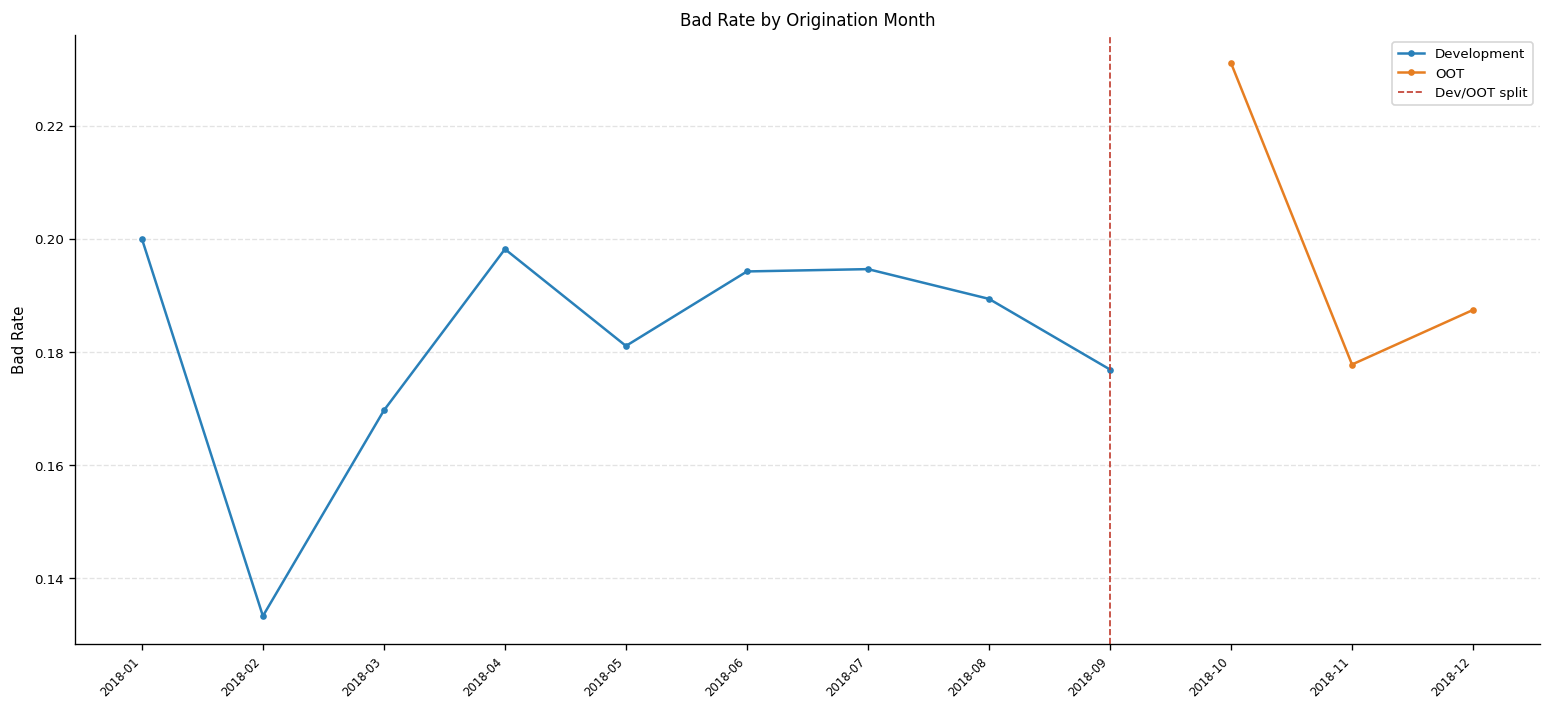

In [168]:
# ── Bad rate by origination month ────────────────────────────────────────────
# Adjust 'origination_date' to the actual date column name in your data

DATE_COL = 'disbursal_date'  # <-- update this

fig, ax = plt.subplots(figsize=(13, 6))

for df, label, color in [
    (dev_df, 'Development', '#2980b9'),
    (oot_df, 'OOT',         '#e67e22'),
]:
    monthly = (
        df.assign(month=pd.to_datetime(df[DATE_COL]).dt.to_period('M'))
        .groupby('month')["loan_default"].mean()
    )
    ax.plot(monthly.index.astype(str), monthly.values,
            label=label, color=color, marker='o', markersize=3)

ax.axvline(x=pd.to_datetime(DEV_END).strftime('%Y-%m'), color='#c0392b', linestyle='--', linewidth=1, label='Dev/OOT split')
ax.set_title('Bad Rate by Origination Month')
ax.set_ylabel('Bad Rate')
ax.legend()
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
# plt.savefig(f'{PLOT_DIR}/phase0_bad_rate_monthly.png', dpi=150, bbox_inches='tight')
plt.show()

In [169]:
# ── Descriptive statistics ───────────────────────────────────────────────────
print('Development sample:')
print(dev_df[DEAL_VARS + [EQUIFAX_COL]].describe().round(2))


Development sample:
            ltv  asset_cost  disbursed_amount  credit_score
count  60268.00    60268.00          60268.00      60268.00
mean      75.90    73547.73          53486.69        649.26
std       11.14    18273.85          12527.15        154.62
min       15.30    37000.00          13664.00        300.00
25%       70.14    64130.00          46369.00        593.00
50%       78.15    68837.50          53003.00        698.00
75%       84.54    76111.00          59207.00        749.00
max       95.00   459625.00         332045.00        890.00


In [172]:
# ── Cut point specification ───────────────────────────────────────────────────
# Update cut points based on quantile analysis and business knowledge
# Leave a variable out of this dict to use equal-frequency auto-binning

CUSTOMER_CUT_POINTS = {
    # 'annual_income':     [15000, 25000, 40000, 65000],
    # 'months_at_address': [6, 24, 60],
    # 'employment_status' → categorical, handled via var_types
}

DEAL_CUT_POINTS = {
    # 'ltv_ratio':         [60, 80, 100, 110],
    # 'deposit_pct':       [5, 10, 15, 20],
    # 'loan_term_months':  [24, 36, 48],
    # 'instalment_amount': [200, 350, 500],
}

CUSTOMER_VAR_TYPES = {
    # 'employment_status': 'categorical',
}

pipeline.run_binning(
    customer_cut_points = CUSTOMER_CUT_POINTS,
    deal_cut_points     = DEAL_CUT_POINTS,
    customer_var_types  = CUSTOMER_VAR_TYPES,
)

dev_woe = pipeline.dev_woe
oot_woe = pipeline.oot_woe

STEP 2: Binning variables

  Customer Variables:

IV SUMMARY
Variable                           IV  Rating                         Issues
-----------------------------------------------------------------
age_at_application              0.013  Useless                        WoE is non-monotonic — consider adjusting cut points or merging unstable bins.

  Deal Variables:

IV SUMMARY
Variable                           IV  Rating                         Issues
-----------------------------------------------------------------
ltv                             0.055  Weak                           WoE is non-monotonic — consider adjusting cut points or merging unstable bins.
disbursed_amount                0.035  Weak                           WoE is non-monotonic — consider adjusting cut points or merging unstable bins.
asset_cost                      0.003  Useless                        WoE is non-monotonic — consider adjusting cut points or merging unstable bins.


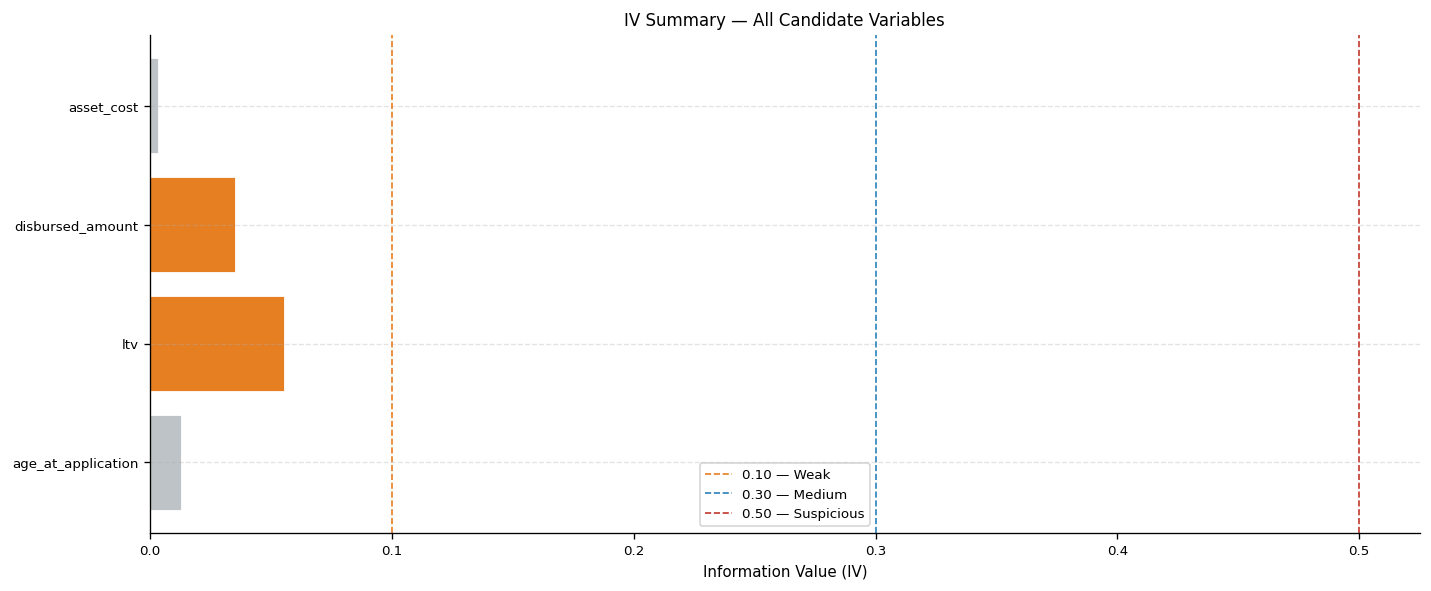

In [173]:
# ── IV bar chart ─────────────────────────────────────────────────────────────
iv_all = pd.concat([
    pipeline.customer_binner.iv_summary.assign(component='Customer'),
    pipeline.deal_binner.iv_summary.assign(component='Deal'),
])

color_map = {
    'Useless': '#bdc3c7', 'Weak': '#e67e22', 'Medium': '#2980b9',
    'Strong': '#27ae60', 'Suspiciously Strong — check for data leakage': '#c0392b',
}

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(
    iv_all['variable'], iv_all['iv'],
    color=[color_map.get(r, '#7f8c8d') for r in iv_all['rating']],
    edgecolor='white', linewidth=0.5,
)
ax.axvline(0.10, color='#e67e22', linestyle='--', linewidth=1, label='0.10 — Weak')
ax.axvline(0.30, color='#2980b9', linestyle='--', linewidth=1, label='0.30 — Medium')
ax.axvline(0.50, color='#c0392b', linestyle='--', linewidth=1, label='0.50 — Suspicious')
ax.set_xlabel('Information Value (IV)')
ax.set_title('IV Summary — All Candidate Variables')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/phase1_iv_summary.png', dpi=150, bbox_inches='tight')
plt.show()

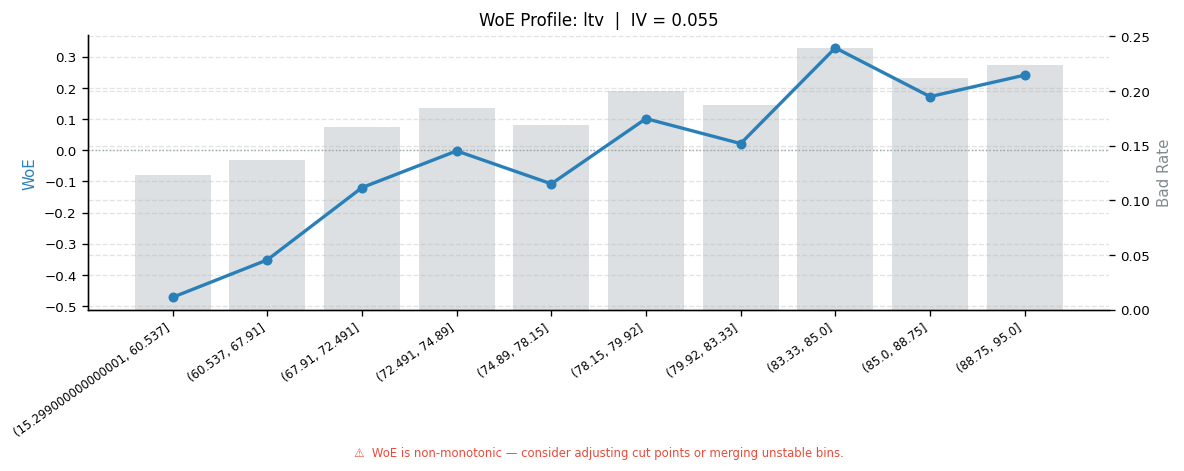

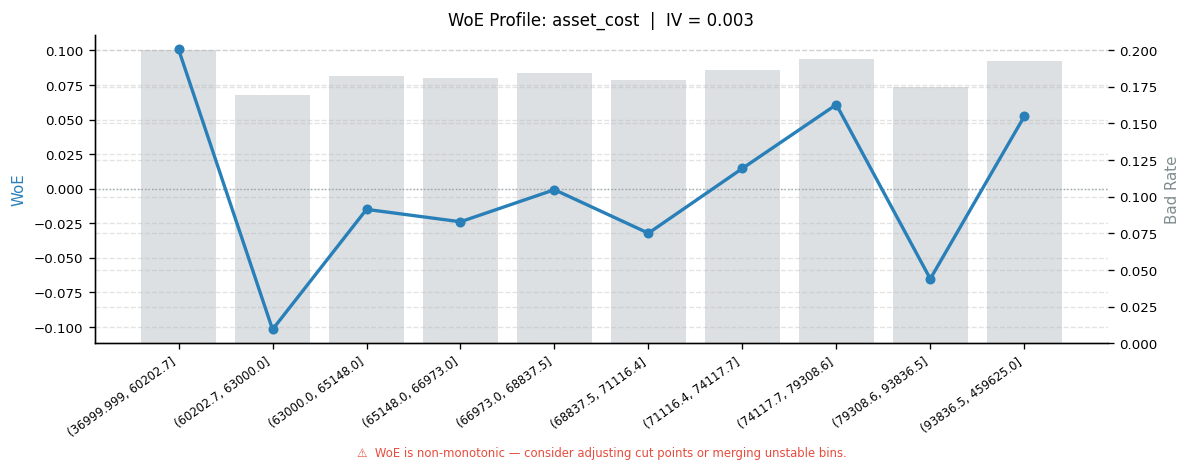

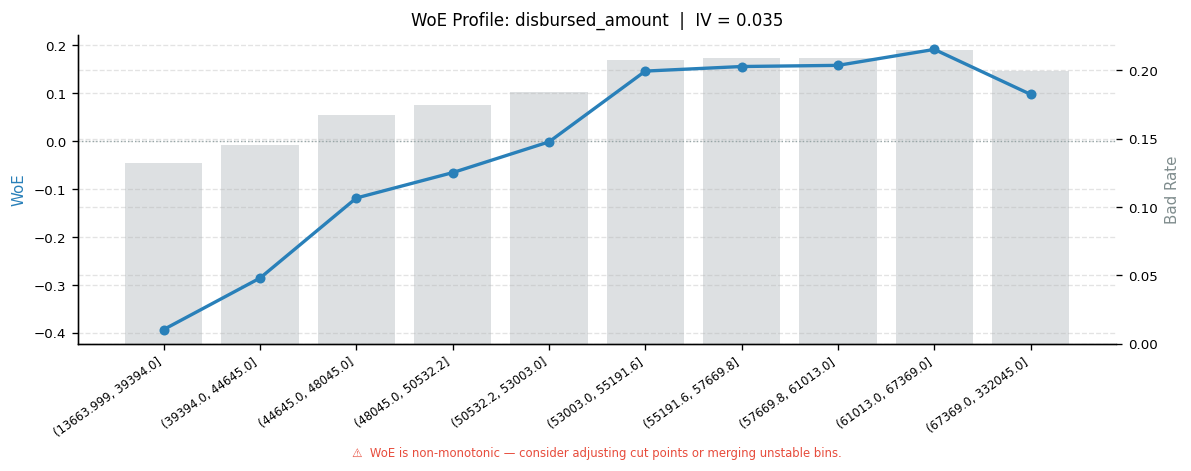

In [174]:
# ── WoE profile plots — one per variable ─────────────────────────────────────
vars_to_plot = DEAL_VARS   # change to CUSTOMER_VARS or a specific subset as needed

for var in vars_to_plot:
    binner = pipeline.deal_binner
    if var not in binner._configs:
        continue
    bs = binner.get_bin_stats(var)
    if bs is None or bs.empty:
        continue

    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax2 = ax1.twinx()

    x = np.arange(len(bs))
    ax2.bar(x, bs['bad_rate'], color='#bdc3c7', alpha=0.5, label='Bad Rate')
    ax1.plot(x, bs['woe'], color='#2980b9', linewidth=2,
             marker='o', markersize=5, label='WoE', zorder=3)
    ax1.axhline(0, color='#95a5a6', linewidth=0.8, linestyle=':')

    ax1.set_xticks(x)
    ax1.set_xticklabels([str(b) for b in bs['bin']], rotation=35, ha='right', fontsize=7)
    ax1.set_ylabel('WoE', color='#2980b9')
    ax2.set_ylabel('Bad Rate', color='#7f8c8d')
    ax1.set_title(f'WoE Profile: {var}  |  IV = {binner._configs[var]["binner"].iv:.3f}')
    ax1.set_zorder(ax2.get_zorder() + 1)
    ax1.patch.set_visible(False)

    issues = binner._configs[var]['binner'].validation_issues
    if issues:
        ax1.set_xlabel(f'⚠️  {issues[0]}', fontsize=7, color='#e74c3c')

    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/phase1_woe_{var}.png', dpi=150, bbox_inches='tight')
    plt.show()


In [175]:
interaction_pipeline = InteractionScorecardPipeline(
    target         = TARGET,
    equifax_col    = EQUIFAX_COL,
    deal_variables = DEAL_VARS,
    pdo            = PDO,
    base_score     = BASE_SCORE,
    base_odds      = BASE_ODDS,
)

# Run log-odds analysis — generates 4-panel plot per variable + model comparison summary
logodds_output = interaction_pipeline.log_odds_analysis(
    df                   = dev_df,
    n_bands              = 4,
    band_labels          = ['Sub-Prime', 'Near-Prime', 'Prime', 'Super-Prime'],
    run_model_comparison = True,
    plot                 = True,
    plot_save_dir        = f'{PLOT_DIR}/phase1_logodds',
)

logodds_results    = logodds_output['log_odds_results']
logodds_model_comp = logodds_output['model_comparison']



LOG-ODDS ANALYSIS: Deal Variables vs Default

  DEAL VARIABLE LOG-ODDS ANALYSIS
  Equifax bands: ['Sub-Prime', 'Near-Prime', 'Prime', 'Super-Prime']


────────────────────────────────────────────────────────────────────────
  VARIABLE: LTV
────────────────────────────────────────────────────────────────────────

  Overall Log-Odds per Bin
  --------------------------------------------------
                         bin  n_total  n_bads  n_goods  bad_rate  log_odds  bin_midpoint  sparse
(15.299000000000001, 60.537]     6027     745     5282    0.1236   -1.9587       37.9180   False
             (60.537, 67.91]     6042     829     5213    0.1372   -1.8387       64.2235   False
             (67.91, 72.491]     6012    1004     5008    0.1670   -1.6070       70.2005   False
             (72.491, 74.89]     6043    1112     4931    0.1840   -1.4894       73.6905   False
              (74.89, 78.15]     6011    1014     4997    0.1687   -1.5949       76.5200   False
              (78.15, 7